# Eigenmode: the TESLA elliptical cavity

This example runs the eigenmode solver on the canonical TESLA elliptical cell — the fundamental accelerating mode and its figures of merit, then the monopole and dipole passbands and the mode-reconstructed impedance. Everything is driven through the `cav.eigenmode` interface on a single cavity (no `Study` needed).

See the [eigenmode theory](../../theory/eigenmode) and [user guide](../../eigenmode).

In [1]:
import os
import tempfile

import matplotlib.pyplot as plt

from cavsim2d import EllipticalCavity
from cavsim2d.utils.style import apply_style

apply_style()

## 1. The cavity

A single TESLA mid-cell, parameters `[A, B, a, b, Ri, L, Req]` in mm, with beam pipes at both ends.

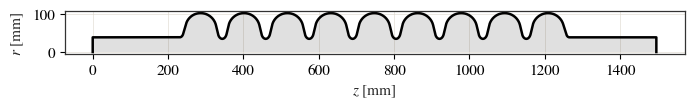

<Axes: xlabel='$z$ [mm]', ylabel='$r$ [mm]'>

In [ ]:
midcell = [42, 42, 12, 19, 35, 57.652, 103.3536]  # <- A, B, a, b, Ri, L, Req
endcell_l = [40.34, 40.34, 10, 13.5, 39, 55.7251, 103.3536]
endcell_r = [42, 42, 9, 12.8, 39, 56.8407, 103.3536]
cav = EllipticalCavity(9, midcell, endcell_l, endcell_r, beampipe='both', name='tesla')
cav.set_workspace(os.path.join(tempfile.mkdtemp(), 'tesla'))

cav.plot('geometry')      # matplotlib half cross-section (r >= 0)

## 2. The fundamental monopole mode

`cav.eigenmode.run(...)` solves the monopole passband; `cav.eigenmode.qois` returns the figures of merit of the accelerating (pi) mode.

In [3]:
cav.eigenmode.run({'polarisation': 'monopole',
                   'boundary_conditions': 'mm',
                   'mesh_config': {'h': 6, 'p': 3}})
cav.eigenmode.qois

{'m': 0,
 'polarisation': 'monopole',
 'Normalization Length [mm]': 115.304,
 'N Cells': 9,
 'freq [MHz]': 1300.006284217142,
 'Q []': 29236.78941926192,
 'Vacc [MV]': 1.516926220044468e-05,
 'Eacc [MV/m]': 1.4617650539679338e-05,
 'Epk [MV/m]': 2.9358256981238297e-05,
 'Hpk [A/m]': 0.048720944078724425,
 'Bpk [mT]': 6.122454399747192e-05,
 'kcc [%]': 1.8299452510193719,
 'ff [%]': 98.3663206837219,
 'Rsh [MOhm]': 29.60974541730714,
 'R/Q [Ohm]': 1012.7563937577737,
 'Epk/Eacc []': 2.008411468145709,
 'Bpk/Eacc [mT/MV/m]': 4.18839839078647,
 'G [Ohm]': 271.30584109965986,
 'GR/Q [Ohm^2]': 274766.7252375111,
 'No of Mesh Elements': 6167,
 'mode_of_interest': '9',
 'No of DOFs': 87608}

The accelerating field on the axis — a single peak at the cell centre, as it should be for the fundamental:

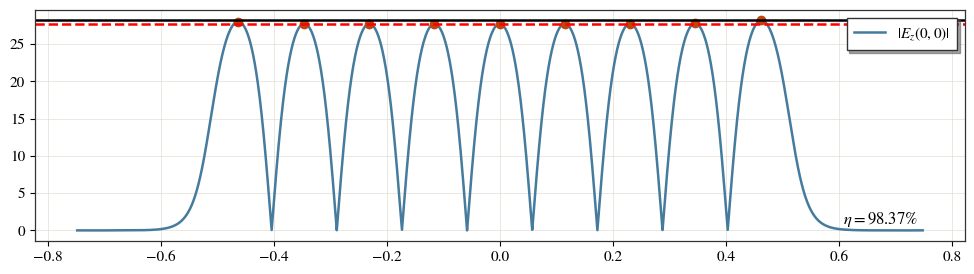

<Axes: >

In [4]:
cav.plot_axis_field()

## 3. Higher-order modes

The same 2D meridian mesh solves any azimuthal order. Here the monopole and dipole passbands together; `qois_df` tabulates every mode of every polarisation. It has many columns, so we show a readable subset:

In [5]:
cav.eigenmode.run({'polarisation': ['monopole', 'dipole', 'quadrupole'],
                   'n_modes': 20,
                   'boundary_conditions': 'mm',
                   'mesh_config': {'h': 6, 'p': 3}})

df = cav.eigenmode.qois_df
cols = ['polarisation', 'freq [MHz]', 'R/Q [Ohm]', 'G [Ohm]',
        'Epk/Eacc []', 'Bpk/Eacc [mT/MV/m]']
df[[c for c in cols if c in df.columns]].round(3).head

<bound method NDFrame.head of    polarisation  freq [MHz]  R/Q [Ohm]  G [Ohm]  Epk/Eacc []  \
0      monopole    1276.433      0.001  268.617     2316.889   
1      monopole    1278.503      0.000  268.886     4795.157   
2      monopole    1281.690      0.009  269.299      819.870   
3      monopole    1285.624      0.001  269.804     3039.467   
4      monopole    1289.841      0.023  270.346      545.599   
..          ...         ...        ...      ...          ...   
61   quadrupole    2490.381      5.949  478.421       26.715   
62   quadrupole    3213.372      0.077  350.529      346.258   
63   quadrupole    3225.450      7.875  359.635       52.668   
64   quadrupole    3229.381      1.228  360.328      111.682   
65   quadrupole    3251.999     19.104  380.535       28.711   

    Bpk/Eacc [mT/MV/m]  
0             5696.033  
1            11699.431  
2             1951.914  
3             7016.717  
4             1237.888  
..                 ...  
61              88.218  
6

The mode spectrum:

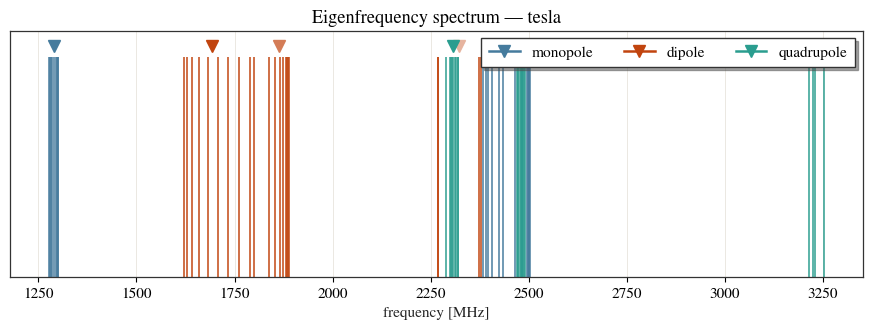

<Axes: title={'center': 'Eigenfrequency spectrum — tesla'}, xlabel='frequency [MHz]'>

In [6]:
cav.eigenmode.plot_spectrum()

## 4. Impedance reconstructed from the modes

Each mode is treated as a resonator, so the eigenmode results reconstruct the beam-coupling impedance directly (see the theory page). This is cheap and has no wake-length truncation, so it complements a wakefield solve.

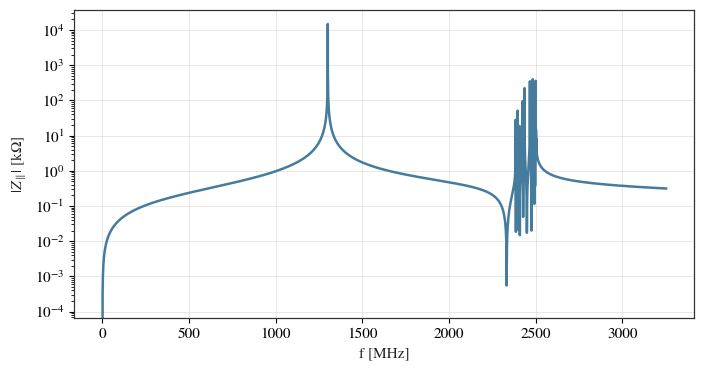

<Axes: xlabel='f [MHz]', ylabel='$|Z_\\parallel|$ [k$\\Omega$]'>

In [7]:
cav.eigenmode.plot_impedance('longitudinal')

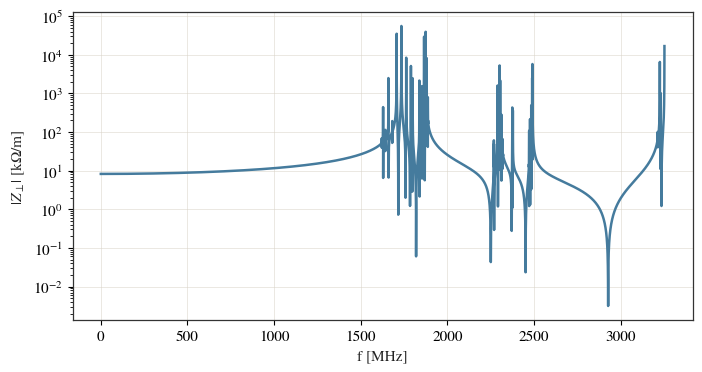

<Axes: xlabel='f [MHz]', ylabel='$|Z_\\perp|$ [k$\\Omega$/m]'>

In [8]:
cav.eigenmode.plot_impedance('transverse')

## Where to go next

- [Eigenmode: the pillbox cavity](pillbox.ipynb) — a fully analytic check of the solver (100 modes vs the closed form).
- Interactive 3D field/mesh views: `cav.show_fields(...)`, `cav.show_mesh()` (NGSolve webgui, notebook-only).
- [Tuning](../tuning/tune_to_frequency.ipynb) to hit a target frequency.